In [3]:
# All necessary imports for Grad-CAM visualization
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [4]:
# Load class mapping and model weights
model_path = '../models/resnet18_brain_tumor_weights.pth'
metadata_path = '../data/processed/preprocessing_metadata.json'

with open(metadata_path, 'r') as f:
    metadata = json.load(f)
class_mapping = metadata['class_mapping']
classes = [class_mapping[str(i)] for i in range(len(class_mapping))]

# Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(weights=None)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = nn.Linear(512, len(classes))
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

/var/folders/bz/l_61zlvj34gcp1c8znmr81rr0000gn/T/ipykernel_45847/3064665665.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path,

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

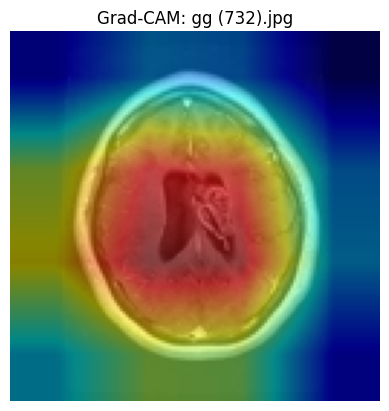

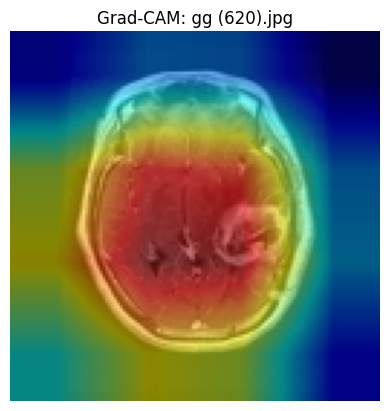

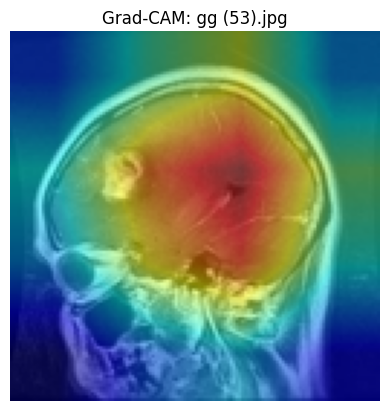

In [10]:
# Grad-CAM setup
target_layer = model.layer4[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

# Define image transform (should match training)
transform = transforms.Compose([
    transforms.Resize((128, 128)), 
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Example: produce Grad-CAM for several images in validation set
image_dir = '../data/processed/Validation/glioma_tumor' 
image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

for img_name in image_files[:3]:  
    img_path = os.path.join(image_dir, img_name)
    img = Image.open(img_path).convert('L')
    input_tensor = transform(img).unsqueeze(0).to(device)

    grayscale_cam = cam(input_tensor=input_tensor)[0]
    img_np = np.array(img.resize((128, 128))) / 255.0
    img_np = np.stack([img_np, img_np, img_np], axis=-1)  

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    plt.imshow(visualization)
    plt.title(f'Grad-CAM: {img_name}')
    plt.axis('off')
    plt.show()